# Reducción de Dimensionalidad: Análisis de Componentes Principales (PCA)

**Teoría:** PCA es una técnica que transforma un conjunto de variables correlacionadas en un nuevo conjunto de variables no correlacionadas llamadas **Componentes Principales**.

**¿Para qué sirve?**
1. **Visualización:** Podemos proyectar datos de muchas dimensiones en 2D o 3D.
2. **Eficiencia:** Reduce el número de variables de entrada para un modelo, manteniendo la mayor cantidad posible de información (varianza).
3. **Eliminar Ruido:** Los componentes con muy poca varianza suelen ser ruido.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## 1. Carga y Preprocesamiento
Usaremos el dataset de Precios de Viviendas en California.

In [2]:
import sys
if 'google.colab' in sys.modules:
    train = pd.read_csv(f'https://raw.githubusercontent.com/dReposU/ML/main/housing.csv')
else:
    train = pd.read_csv("housing.csv")

# Limpieza rápida
train.dropna(inplace=True)
train = train.drop('ocean_proximity', axis=1) # Eliminamos variables categóricas para PCA

x = train.drop(columns='median_house_value')
target = train['median_house_value']

## 2. Estandarización
**¡CRUCIAL!** PCA se basa en la varianza. Si una variable tiene una escala mucho mayor que otra (ej. Ingreso vs Edad), dominará el cálculo injustamente. Siempre debemos usar `StandardScaler` antes de PCA.

In [3]:
x_scaled = StandardScaler().fit_transform(x)

## 3. Aplicación de PCA
Reduciremos las 8 variables originales a solo 2 componentes principales.

In [8]:
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(x_scaled)

# Creamos un DataFrame con los nuevos componentes
principalDf = pd.DataFrame(data = principalComponents, 
                           columns = ['PC1', 'PC2'])

principalDf.head()

,PC1,PC2
0,-2.091848,1.395074
1,2.936717,1.934054
2,-1.968320,1.464482
3,-1.917650,1.505893
4,-1.775537,1.564319


## 4. Varianza Explicada
Es importante saber cuánta información "perdimos" al reducir dimensiones.

In [5]:
varianza = pca.explained_variance_ratio_
print(f"Varianza explicada por PC1: {varianza[0]:.2f}")
print(f"Varianza explicada por PC2: {varianza[1]:.2f}")
print(f"Varianza total acumulada: {np.sum(varianza):.2f}")

Varianza explicada por PC1: 0.49
Varianza explicada por PC2: 0.24
Varianza total acumulada: 0.73


## 5. Visualización
Ahora podemos ver los datos en un plano 2D, donde el color representa el valor de la casa.

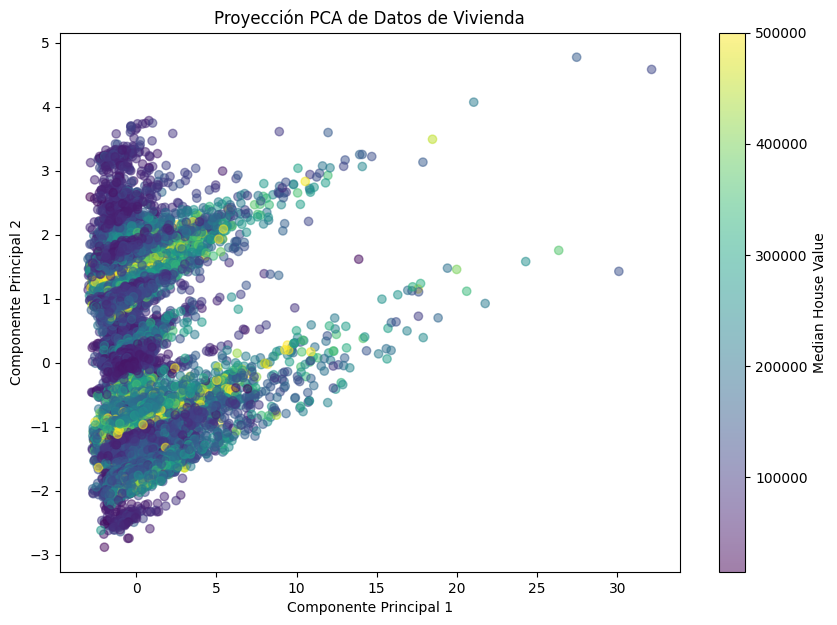

In [6]:
plt.figure(figsize=(10, 7))
plt.scatter(principalDf['PC1'], principalDf['PC2'], c=target, cmap='viridis', alpha=0.5)
plt.colorbar(label='Median House Value')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Proyección PCA de Datos de Vivienda')
plt.show()